In [1]:
import subprocess, sys, os

# ── Check if already installed ─────────────────────────────────────────────
try:
    from mamba_ssm import Mamba
    print('✅ mamba_ssm already installed — skip to Cell 2')

except ImportError:
    print('Building mamba_ssm from GitHub source (not pip tarball)...')
    print('This takes ~10 minutes.\n')

    env = os.environ.copy()
    env['TORCH_CUDA_ARCH_LIST'] = '8.0'       # A100
    env['MAX_JOBS']             = '4'          # parallel compile jobs
    env['CUDA_HOME']            = '/usr/local/cuda'

    # ── Step 1: causal-conv1d from source ────────────────────────────────────
    print('Step 1/3: causal-conv1d from source...')
    if not os.path.exists('/tmp/causal-conv1d'):
        subprocess.run(
            ['git', 'clone', '--depth=1',
             'https://github.com/Dao-AILab/causal-conv1d.git',
             '/tmp/causal-conv1d'],
            check=True
        )
    subprocess.run(
        [sys.executable, 'setup.py', 'install'],
        cwd='/tmp/causal-conv1d',
        env=env,
        check=True
    )
    print('✅ causal-conv1d done\n')

    # ── Step 2: mamba-ssm from source (full repo = has the .cpp files) ───────
    print('Step 2/3: cloning mamba-ssm repo...')
    if not os.path.exists('/tmp/mamba-ssm'):
        subprocess.run(
            ['git', 'clone', '--depth=1',
             'https://github.com/state-spaces/mamba.git',
             '/tmp/mamba-ssm'],
            check=True
        )
    print('Step 3/3: building mamba-ssm CUDA extension (~10 min)...')
    subprocess.run(
        [sys.executable, 'setup.py', 'install'],
        cwd='/tmp/mamba-ssm',
        env=env,
        check=True
    )
    print('✅ mamba-ssm build done\n')

# ── Verify ──────────────────────────────────────────────────────────────────
from mamba_ssm import Mamba
print('✅ mamba_ssm imported successfully')

import torch
m = Mamba(d_model=32, d_state=16, d_conv=4, expand=2).cuda()
x = torch.randn(1, 10, 32).cuda()
y = m(x)
print(f'✅ Mamba forward pass OK: {x.shape} → {y.shape}')
del m, x, y

/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nvidia/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ mamba_ssm already installed — skip to Cell 2
✅ mamba_ssm imported successfully
✅ Mamba forward pass OK: torch.Size([1, 10, 32]) → torch.Size([1, 10, 32])


In [2]:
import os, sys, gc, torch
import numpy as np
import pandas as pd

# ── SAME paths as previous notebook (Cell 2) ─────────────────────────────────
RAW_DATA_DIR     = '/home/nvidia/23BRS1236/mnt/ADHD200/RawDataBIDS'
PREPROCESSED_DIR = '/home/nvidia/23BRS1236/mnt/ADHD200/preprocessed_mni'   # ← already done
NEUROSTORM_INPUT = '/home/nvidia/23BRS1236/mnt/ADHD200/neurostorm_data'     # ← .npy files here
PRETRAINED_CKPT  = '/home/nvidia/23BRS1236/mnt/ADHD200/pretrained_models/neurostorm_mae.pth'
NEUROSTORM_DIR   = './NeuroSTORM'                                            # ← already cloned
MANIFEST_CSV     = './adhd200_manifest_final.csv'                            # ← already built

# ── NEW output dir for this notebook (keeps previous results safe) ────────────
OUTPUT_DIR = '/home/nvidia/23BRS1236/mnt/ADHD200/runs/neurostorm_true'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Training settings ─────────────────────────────────────────────────────────
BATCH_SIZE  = 2       # keep same as before (large 4D volumes)
MAX_EPOCHS  = 50
LR          = 1e-4
NUM_CLASSES = 2
PROMPT_LEN  = 50      # VPT-Deep: 50 learnable tokens per transformer block

# ── NeuroSTORM architecture (official defaults from the paper) ─────────────────
# Input: (B, 1, 96, 96, 96, 20) — batch, channel, X, Y, Z, time
IMG_SIZE          = [96, 96, 96, 20]  # spatial 96³ + 20 timepoints per window
PATCH_SIZE        = [6, 6, 6, 1]      # divide each spatial dim by 6
WINDOW_SIZE       = [4, 4, 4, 4]
FIRST_WINDOW_SIZE = [2, 2, 2, 2]
EMBED_DIM         = 36
DEPTHS            = [2, 2, 6, 2]
NUM_HEADS         = [3, 6, 12, 24]
C_MULTIPLIER      = 2
# final feature size = 36 * 2^3 = 288 channels, spatial 2x2x2, time 20
# num_tokens for head = 2*2*2*20 = 160
NUM_TOKENS        = 160

# ── Use GPU 4 (free 80GB A100, same as before) ────────────────────────────────
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
gc.collect()
torch.cuda.empty_cache()
device = torch.device('cuda')

# Add NeuroSTORM to Python path
for p in [NEUROSTORM_DIR,
          f'{NEUROSTORM_DIR}/models',
          f'{NEUROSTORM_DIR}/datasets',
          f'{NEUROSTORM_DIR}/utils']:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── Verify everything exists ──────────────────────────────────────────────────
assert os.path.exists(MANIFEST_CSV),   f'❌ Manifest not found: {MANIFEST_CSV}'
assert os.path.isdir(PREPROCESSED_DIR), f'❌ Preprocessed dir not found: {PREPROCESSED_DIR}'
assert os.path.isdir(NEUROSTORM_DIR),   f'❌ NeuroSTORM repo not found: {NEUROSTORM_DIR}'

print(f'Device  : {device}  ({torch.cuda.get_device_name(0)})')
print(f'Free GPU: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved()) / 1e9:.1f} GB')
print(f'Manifest: {MANIFEST_CSV} ✅')
print(f'PreProc : {PREPROCESSED_DIR} ✅')
print(f'NeuroSTORM repo: {NEUROSTORM_DIR} ✅')

Device  : cuda  (NVIDIA A100-SXM4-80GB)
Free GPU: 85.1 GB
Manifest: ./adhd200_manifest_final.csv ✅
PreProc : /home/nvidia/23BRS1236/mnt/ADHD200/preprocessed_mni ✅
NeuroSTORM repo: ./NeuroSTORM ✅


In [5]:
import pandas as pd, os

# Load manifest built by previous notebook
manifest = pd.read_csv(MANIFEST_CSV)

print(f'Total subjects : {len(manifest)}')
print(f'Columns        : {list(manifest.columns)}')
print(f'\nSplit breakdown:')
for split, grp in manifest.groupby('split'):
    vc = grp['label'].value_counts()
    print(f'  {split:5s} | ADHD={vc.get(1,0):3d}  Control={vc.get(0,0):3d}  Total={len(grp)}')

# Verify preprocessed .nii.gz files exist
n_preproc = sum(os.path.exists(p) for p in manifest['preproc_path'])
print(f'\nPreprocessed .nii.gz files on disk: {n_preproc} / {len(manifest)}')

if n_preproc == 0:
    print('❌ No preprocessed files found — check PREPROCESSED_DIR and preproc_path column')
else:
    print(f'Sample path: {manifest["preproc_path"].iloc[0]}')
    print('✅ Ready to build NeuroSTORM dataset')

Total subjects : 626
Columns        : ['subject_id', 'subject_num', 'site', 'raw_fmri', 'label', 'preproc_ok', 'preproc_path', 'shape_ok', 'split', 'pt_path', 'pt_ok']

Split breakdown:
  test  | ADHD= 25  Control= 38  Total=63
  train | ADHD=201  Control=299  Total=500
  val   | ADHD= 26  Control= 37  Total=63

Preprocessed .nii.gz files on disk: 626 / 626
Sample path: /home/nvidia/23BRS1236/mnt/ADHD200/preprocessed_mni/NYU/sub-4562206_NYU_preproc.nii.gz
✅ Ready to build NeuroSTORM dataset


In [6]:
import torch
import nibabel as nib
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader


def center_crop_3d(data, target=96):
    """
    Center-crop or zero-pad each spatial dimension to `target` voxels.
    Input:  numpy array (X, Y, Z, T)
    Output: numpy array (target, target, target, T)
    """
    result = data
    for axis in range(3):
        size = result.shape[axis]
        if size >= target:
            start  = (size - target) // 2
            slices = [slice(None)] * 4
            slices[axis] = slice(start, start + target)
            result = result[tuple(slices)]
        else:
            pad_b  = (target - size) // 2
            pad_a  = target - size - pad_b
            pw     = [(0, 0)] * 4
            pw[axis] = (pad_b, pad_a)
            result = np.pad(result, pw, mode='constant', constant_values=0)
    return result   # (96, 96, 96, T)


class NeuroSTORMDataset(Dataset):
    """
    Loads preprocessed .nii.gz files (already in MNI space from previous notebook),
    center-crops to 96x96x96, samples T=20 consecutive timepoints, and returns
    tensors in NeuroSTORM's required format: (1, 96, 96, 96, 20).
    
    Note: reads from preproc_path (.nii.gz), NOT the .npy files,
    because NeuroSTORM needs the original float signal, not int8-quantized.
    """
    def __init__(self, df, split='train', seq_len=80, augment=True):
        self.df      = df[df['split'] == split].reset_index(drop=True)
        self.seq_len = seq_len
        self.augment = augment and (split == 'train')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = row['preproc_path']   # .nii.gz from previous notebook's preprocessing

        # Load 4D fMRI: (X, Y, Z, T)
        img  = nib.load(path)
        data = img.get_fdata(dtype=np.float32)  # (99, 117, 95, 246)

        # Center-crop spatial dims to 96x96x96
        data = center_crop_3d(data, target=96)  # (96, 96, 96, 246)

        T = data.shape[3]

        # Sample a contiguous window of seq_len timepoints
        if T >= self.seq_len:
            if self.augment:
                start = random.randint(0, T - self.seq_len)
            else:
                start = (T - self.seq_len) // 2  # always center window
            data = data[..., start:start + self.seq_len]  # (96, 96, 96, 20)
        else:
            # Pad time if shorter than seq_len (rare)
            pad = np.zeros((96, 96, 96, self.seq_len - T), dtype=np.float32)
            data = np.concatenate([data, pad], axis=3)

        # NeuroSTORM expects: (1, X, Y, Z, T)  — channel-first, time last
        data = data[np.newaxis, ...]        # (1, 96, 96, 96, 20)
        tensor = torch.from_numpy(data.copy())

        label  = torch.tensor(int(row['label']), dtype=torch.long)
        return tensor, label


# ── Build datasets and loaders ────────────────────────────────────────────────
train_dataset = NeuroSTORMDataset(manifest, split='train', seq_len=20)
val_dataset   = NeuroSTORMDataset(manifest, split='val',   seq_len=20, augment=False)
test_dataset  = NeuroSTORMDataset(manifest, split='test',  seq_len=20, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'Train : {len(train_dataset)} subjects → {len(train_loader)} batches')
print(f'Val   : {len(val_dataset)} subjects → {len(val_loader)} batches')
print(f'Test  : {len(test_dataset)} subjects → {len(test_loader)} batches')

# Sanity check: load one batch and check shape
print('\nLoading one batch to check shape (takes ~10s — loading .nii.gz from disk)...')
x_sample, y_sample = next(iter(train_loader))
print(f'x shape : {x_sample.shape}  ← must be (B, 1, 96, 96, 96, 20)')
print(f'y shape : {y_sample.shape}')
print(f'labels  : {y_sample.tolist()}')
print(f'x range : [{x_sample.min():.3f}, {x_sample.max():.3f}]  (z-scored signal, ~[-4, 4])')
del x_sample, y_sample
torch.cuda.empty_cache()
print('✅ DataLoaders ready')

Train : 500 subjects → 250 batches
Val   : 63 subjects → 32 batches
Test  : 63 subjects → 32 batches

Loading one batch to check shape (takes ~10s — loading .nii.gz from disk)...
x shape : torch.Size([2, 1, 96, 96, 96, 20])  ← must be (B, 1, 96, 96, 96, 20)
y shape : torch.Size([2])
labels  : [0, 0]
x range : [-5.539, 8.324]  (z-scored signal, ~[-4, 4])
✅ DataLoaders ready


In [7]:
import os
from huggingface_hub import hf_hub_download

PRETRAINED_CKPT = '/home/nvidia/23BRS1236/mnt/ADHD200/pretrained_models/neurostorm_mae.pth'
os.makedirs(os.path.dirname(PRETRAINED_CKPT), exist_ok=True)

if os.path.exists(PRETRAINED_CKPT):
    size_mb = os.path.getsize(PRETRAINED_CKPT) / 1e6
    print(f'✅ Already exists: {PRETRAINED_CKPT}  ({size_mb:.0f} MB)')
else:
    print('Downloading from Hugging Face: zxcvb20001/NeuroSTORM ...')
    # This is the exact repo and path used by NeuroSTORM's own main.py
    downloaded = hf_hub_download(
        repo_id = 'zxcvb20001/NeuroSTORM',
        filename = 'neurostorm/neurostorm_mae.pth',
        local_dir = os.path.dirname(PRETRAINED_CKPT),
    )
    # hf_hub_download saves to local_dir/neurostorm/neurostorm_mae.pth
    # move it to the flat path our notebook expects
    import shutil
    nested = os.path.join(os.path.dirname(PRETRAINED_CKPT), 'neurostorm', 'neurostorm_mae.pth')
    if os.path.exists(nested) and nested != PRETRAINED_CKPT:
        shutil.move(nested, PRETRAINED_CKPT)

    size_mb = os.path.getsize(PRETRAINED_CKPT) / 1e6
    print(f'✅ Downloaded: {size_mb:.0f} MB → {PRETRAINED_CKPT}')

✅ Already exists: /home/nvidia/23BRS1236/mnt/ADHD200/pretrained_models/neurostorm_mae.pth  (93 MB)


In [8]:
import os, shutil
from huggingface_hub import hf_hub_download

PRETRAINED_CKPT = '/home/nvidia/23BRS1236/mnt/ADHD200/pretrained_models/neurostorm_mae.pth'
os.makedirs(os.path.dirname(PRETRAINED_CKPT), exist_ok=True)

print('Downloading pt_neurostorm_mae_5ds.ckpt from HuggingFace...')
print('(5ds = pretrained on 5 datasets: UKB, ABCD, HCP-YA, HCP-A, HCP-D)\n')

path = hf_hub_download(
    repo_id  = 'zxcvb20001/NeuroSTORM',
    filename = 'pretraining/pt_neurostorm_mae_5ds.ckpt',
)

print(f'Downloaded to cache: {path}')
print(f'Size: {os.path.getsize(path)/1e6:.0f} MB')

# Copy to our target path (rename to .pth as our notebook expects)
shutil.copy2(path, PRETRAINED_CKPT)
print(f'\n✅ Saved to: {PRETRAINED_CKPT}')
print(f'   Size: {os.path.getsize(PRETRAINED_CKPT)/1e6:.0f} MB')

# Verify it loads correctly
import torch
print('\nVerifying checkpoint...')
ckpt = torch.load(PRETRAINED_CKPT, map_location='cpu', weights_only=False)
print(f'Type       : {type(ckpt)}')
if isinstance(ckpt, dict):
    print(f'Keys       : {list(ckpt.keys())}')
    state = ckpt.get('state_dict') or ckpt.get('model') or ckpt
    print(f'Num tensors: {len(state)}')
    print(f'Sample keys: {list(state.keys())[:5]}')
print('\n✅ Checkpoint valid — proceed to Cell 6')

(5ds = pretrained on 5 datasets: UKB, ABCD, HCP-YA, HCP-A, HCP-D)

Downloaded to cache: /home/nvidia/.cache/huggingface/hub/models--zxcvb20001--NeuroSTORM/snapshots/b99c7460b3a2904af82001895fa49a17ad72723e/pretraining/pt_neurostorm_mae_5ds.ckpt
Size: 93 MB

✅ Saved to: /home/nvidia/23BRS1236/mnt/ADHD200/pretrained_models/neurostorm_mae.pth
   Size: 93 MB

Verifying checkpoint...
Type       : <class 'dict'>
Keys       : ['epoch', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters', 'datamodule_hparams_name', 'datamodule_hyper_parameters']
Num tensors: 409
Sample keys: ['model.mask_token', 'model.window_mask_token', 'model.atlas_mask_token', 'model.patch_embed.fc.weight', 'model.patch_embed.fc.bias']

✅ Checkpoint valid — proceed to Cell 6


In [9]:
import torch, gc, os
import torch.nn as nn
import torch.nn.functional as F
gc.collect()
torch.cuda.empty_cache()

from models.neurostorm import NeuroSTORM

IMG_SIZE_NEW = [96, 96, 96, 80]
NUM_TOKENS   = 2 * 2 * 2 * 80   # = 640

backbone = NeuroSTORM(
    img_size          = IMG_SIZE_NEW,
    in_chans          = 1,
    embed_dim         = EMBED_DIM,
    window_size       = WINDOW_SIZE,
    first_window_size = FIRST_WINDOW_SIZE,
    patch_size        = PATCH_SIZE,
    depths            = DEPTHS,
    num_heads         = NUM_HEADS,
    c_multiplier      = C_MULTIPLIER,
    last_layer_full_MSA = False,
    num_classes       = NUM_CLASSES,
    prompt_len        = PROMPT_LEN,
)

# ── Load and fix checkpoint ───────────────────────────────────────────────────
print('Loading pretrained checkpoint...')
ckpt = torch.load(PRETRAINED_CKPT, map_location='cpu', weights_only=False)

if isinstance(ckpt, dict) and 'state_dict' in ckpt:
    raw   = ckpt['state_dict']
    state = {}
    for k, v in raw.items():
        new_k = k[len('model.'):] if k.startswith('model.') else k
        new_k = new_k[len('backbone.'):] if new_k.startswith('backbone.') else new_k
        state[new_k] = v
else:
    state = ckpt.get('model') or ckpt.get('model_state_dict') or ckpt

# ── Interpolate time_embed from T=20 → T=80 ──────────────────────────────────
# pos_embeds.i.time_embed shape: (1, C, 1, 1, 1, T_old) → (1, C, 1, 1, 1, T_new)
T_old = 20
T_new = 80
print(f'Interpolating time_embed: T={T_old} → T={T_new}')

time_embed_keys = [k for k in state.keys() if 'time_embed' in k]
print(f'Found {len(time_embed_keys)} time_embed tensors: {time_embed_keys}')

for key in time_embed_keys:
    old_embed = state[key]               # (1, C, 1, 1, 1, T_old)
    C = old_embed.shape[1]

    # Reshape to (1, C, T_old) for 1D interpolation, then back
    old_2d = old_embed.squeeze(0).squeeze(-2).squeeze(-2).squeeze(-2)  # (C, T_old)
    old_2d = old_2d.unsqueeze(0)                                        # (1, C, T_old)

    # Linear interpolation along time dimension
    new_2d = F.interpolate(old_2d, size=T_new, mode='linear',
                           align_corners=False)                          # (1, C, T_new)

    # Reshape back to original format: (1, C, 1, 1, 1, T_new)
    new_embed = new_2d.squeeze(0).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)  # (C, 1,1,1, T_new)
    new_embed = new_embed.unsqueeze(0)                                        # (1,C,1,1,1,T_new)
    # Fix dim order: need (1, C, 1, 1, 1, T_new)
    new_embed = new_2d.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)             # (1,C,T,1,1,1) wrong
    # Correct reshape:
    new_embed = new_2d.view(1, C, 1, 1, 1, T_new)

    state[key] = new_embed
    print(f'  {key}: {old_embed.shape} → {new_embed.shape}')

# ── Load state dict (now shapes match) ───────────────────────────────────────
missing, unexpected = backbone.load_state_dict(state, strict=False)
print(f'\nMissing keys   : {len(missing)}')
print(f'Unexpected keys: {len(unexpected)}')

# Verify patch_embed loaded correctly
sample_key = 'patch_embed.proj.weight'
if sample_key in state:
    ckpt_norm = torch.norm(state[sample_key]).item()
    model_norm = torch.norm(dict(backbone.named_parameters())[sample_key]).item()
    print(f'Weight check (patch_embed): ckpt={ckpt_norm:.4f}  model={model_norm:.4f}  '
          f'match={abs(ckpt_norm-model_norm)<0.01} ✅')

# ── Classifier head ───────────────────────────────────────────────────────────
class NeuroSTORMClassifier(nn.Module):
    def __init__(self, backbone, num_tokens=640, num_classes=2):
        super().__init__()
        self.backbone    = backbone
        self.norm        = nn.LayerNorm(num_tokens)
        self.dropout     = nn.Dropout(0.3)
        self.head_linear = nn.Linear(num_tokens, num_classes)

    def forward(self, x):
        feat = self.backbone(x)                      # (B, 288, 2, 2, 2, 80)
        B, C, D, H, W, T = feat.shape
        pooled = feat.reshape(B, C, -1).mean(dim=1)  # (B, 640)
        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)
        return self.head_linear(pooled)               # (B, 2)

model = NeuroSTORMClassifier(backbone, num_tokens=NUM_TOKENS, num_classes=NUM_CLASSES)

# ── Unfreeze last 2 stages + head ─────────────────────────────────────────────
frozen_n, trainable_n = 0, 0
for name, param in model.named_parameters():
    is_late   = any(f'layers.{i}.' in name for i in [2, 3])
    is_head   = any(k in name for k in ['head_linear', 'norm', 'dropout'])
    is_prompt = 'prompt' in name.lower()
    is_pnorm  = 'patch_norm' in name

    if is_late or is_head or is_prompt or is_pnorm:
        param.requires_grad = True
        trainable_n += param.numel()
    else:
        param.requires_grad = False
        frozen_n += param.numel()

total = frozen_n + trainable_n
print(f'\nFrozen   : {frozen_n:>10,}  (stages 0-1)')
print(f'Trainable: {trainable_n:>10,}  (stages 2-3 + prompt + head)')
print(f'% updated: {100*trainable_n/total:.1f}%')

# ── Move to GPU + verify ──────────────────────────────────────────────────────
model = model.to(device)
with torch.no_grad():
    dummy = torch.zeros(1, 1, 96, 96, 96, 80, device=device)
    out   = model(dummy)
    print(f'\n✅ Forward pass: {tuple(dummy.shape)} → {tuple(out.shape)}')
    del dummy, out
torch.cuda.empty_cache()
print(f'GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'\n✅ NeuroSTORM ready — {trainable_n:,} params will be trained')

Loading pretrained checkpoint...
Interpolating time_embed: T=20 → T=80
Found 4 time_embed tensors: ['pos_embeds.0.time_embed', 'pos_embeds.1.time_embed', 'pos_embeds.2.time_embed', 'pos_embeds.3.time_embed']
  pos_embeds.0.time_embed: torch.Size([1, 36, 1, 1, 1, 20]) → torch.Size([1, 36, 1, 1, 1, 80])
  pos_embeds.1.time_embed: torch.Size([1, 72, 1, 1, 1, 20]) → torch.Size([1, 72, 1, 1, 1, 80])
  pos_embeds.2.time_embed: torch.Size([1, 144, 1, 1, 1, 20]) → torch.Size([1, 144, 1, 1, 1, 80])
  pos_embeds.3.time_embed: torch.Size([1, 288, 1, 1, 1, 20]) → torch.Size([1, 288, 1, 1, 1, 80])

Missing keys   : 12
Unexpected keys: 186

Frozen   :    560,556  (stages 0-1)
Trainable:  4,730,226  (stages 2-3 + prompt + head)
% updated: 89.4%

✅ Forward pass: (1, 1, 96, 96, 96, 80) → (1, 2)
GPU: 0.03 GB

✅ NeuroSTORM ready — 4,730,226 params will be trained


In [10]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# ── Update these two values ───────────────────────────────────────────────────
LR         = 1e-5    # was 1e-4 — 10x lower for fine-tuning pretrained model
MAX_EPOCHS = 100     # was 50 — give more time to converge

# ── Class-weighted loss (same as before) ──────────────────────────────────────
label_counts = manifest[manifest['split']=='train']['label'].value_counts().sort_index()
n_ctrl = label_counts.get(0, 1)
n_adhd = label_counts.get(1, 1)
weight = torch.tensor([1.0/n_ctrl, 1.0/n_adhd], dtype=torch.float32)
weight = weight / weight.sum()
criterion = nn.CrossEntropyLoss(weight=weight.to(device))

# ── Only optimise trainable parameters ────────────────────────────────────────
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(trainable_params, lr=LR, weight_decay=1e-4)

# Cosine annealing with warm restarts — better for fine-tuning
# Restarts every 25 epochs: allows escaping local minima
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=25, T_mult=2, eta_min=1e-7)

print(f'Loss       : CrossEntropy  ctrl_w={weight[0]:.3f}  adhd_w={weight[1]:.3f}')
print(f'Optimizer  : AdamW  lr={LR}  wd=1e-4')
print(f'Scheduler  : CosineAnnealingWarmRestarts  T_0=25  eta_min=1e-7')
print(f'Epochs     : {MAX_EPOCHS}')
print(f'Trainable  : {sum(p.numel() for p in trainable_params):,} params')

Loss       : CrossEntropy  ctrl_w=0.402  adhd_w=0.598
Optimizer  : AdamW  lr=1e-05  wd=1e-4
Scheduler  : CosineAnnealingWarmRestarts  T_0=25  eta_min=1e-7
Epochs     : 100
Trainable  : 4,730,226 params


In [8]:
import torch, time

# ── Check if model and data are actually on GPU ───────────────────────────────
print(f'Model device: {next(model.parameters()).device}')
print(f'GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')

# ── Time one batch to see where the bottleneck is ─────────────────────────────
loader_iter = iter(train_loader)

t0 = time.time()
x, y = next(loader_iter)
t1 = time.time()
print(f'\nData loading time (1 batch from disk): {t1-t0:.2f}s  ← this is the bottleneck')

x = x.to(device, dtype=torch.float32)
y = y.to(device, dtype=torch.long)
t2 = time.time()
print(f'CPU→GPU transfer time               : {t2-t1:.2f}s')

with torch.no_grad():
    out = model(x)
t3 = time.time()
print(f'GPU forward pass time               : {t3-t2:.2f}s  ← this should be fast')
print(f'\nBottleneck is {"DISK IO (loading .nii.gz)" if (t1-t0) > (t3-t2) else "GPU compute"}')
del x, y, out
torch.cuda.empty_cache()

Model device: cuda:0
GPU memory allocated: 0.03 GB

Data loading time (1 batch from disk): 12.21s  ← this is the bottleneck
CPU→GPU transfer time               : 0.06s


RuntimeError: Given normalized_shape=[640], expected input with shape [*, 640], but got input of size[2, 160]

In [ ]:
import nibabel as nib, numpy as np, os, time, gc, torch, random
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

NPY_DIR = '/home/nvidia/23BRS1236/mnt/ADHD200/preprocessed_npy96'
os.makedirs(NPY_DIR, exist_ok=True)

def center_crop_3d(data, target=96):
    result = data
    for axis in range(3):
        size = result.shape[axis]
        if size >= target:
            start  = (size - target) // 2
            slices = [slice(None)] * 4
            slices[axis] = slice(start, start + target)
            result = result[tuple(slices)]
        else:
            pad_b = (target - size) // 2
            pad_a = target - size - pad_b
            pw = [(0,0)] * 4
            pw[axis] = (pad_b, pad_a)
            result = np.pad(result, pw, mode='constant')
    return result  # (96, 96, 96, T)

# ── Step 1: One-time conversion of .nii.gz → .npy (run once, skip if done) ───
print('Step 1: Converting .nii.gz → .npy (skips already-converted files)...')
t0 = time.time()
converted, skipped = 0, 0

for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
    npy_path = os.path.join(NPY_DIR, f"{row['subject_id']}_{row['site']}.npy")
    if os.path.exists(npy_path):
        skipped += 1
        continue
    try:
        img  = nib.load(row['preproc_path'])
        data = img.get_fdata(dtype=np.float32)   # (99, 117, 95, 246)
        data = center_crop_3d(data, target=96)    # (96, 96, 96, 246)
        np.save(npy_path, data)                   # saves uncompressed — loads in ~0.1s
        converted += 1
    except Exception as e:
        print(f'  ⚠️  {row["subject_id"]}: {e}')

print(f'Converted: {converted}  |  Skipped (already done): {skipped}')
print(f'Time: {(time.time()-t0)/60:.1f} min')

# ── Step 2: Add npy_path column to manifest ───────────────────────────────────
manifest['npy_path'] = [
    os.path.join(NPY_DIR, f"{row['subject_id']}_{row['site']}.npy")
    for _, row in manifest.iterrows()
]
n_exist = sum(os.path.exists(p) for p in manifest['npy_path'])
print(f'\n.npy files on disk: {n_exist} / {len(manifest)}')


# ── Step 3: RAM-cached Dataset (now loads .npy — takes seconds not hours) ─────
class CachedNeuroSTORMDataset(Dataset):
    """
    Loads all .npy files into RAM at startup.
    .npy loads in ~0.1s vs .nii.gz which took ~10s.
    626 × ~35MB float32 = ~22GB RAM — fine for a research server.
    Stores as float16 to halve RAM to ~11GB.
    """
    def __init__(self, df, split='train', seq_len=80, augment=True):
        self.df      = df[df['split'] == split].reset_index(drop=True)
        self.seq_len = seq_len
        self.augment = augment and (split == 'train')
        self.cache   = {}

        print(f'\n[{split}] Loading {len(self.df)} subjects into RAM...')
        t0     = time.time()
        failed = 0

        for i, (_, row) in enumerate(self.df.iterrows()):
            npy = row['npy_path']
            try:
                data = np.load(npy)                       # (96, 96, 96, 246) float32
                self.cache[i] = data.astype(np.float16)  # store as float16 → half RAM
            except Exception as e:
                print(f'  ⚠️  {row["subject_id"]}: {e}')
                self.cache[i] = None
                failed += 1

        elapsed = time.time() - t0
        print(f'✅ [{split}] {len(self.df)-failed}/{len(self.df)} subjects '
              f'loaded in {elapsed:.1f}s  ({elapsed/60:.1f} min)')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        data = self.cache[idx]

        if data is None:
            dummy = np.zeros((1, 96, 96, 96, self.seq_len), dtype=np.float32)
            return torch.from_numpy(dummy), torch.tensor(0, dtype=torch.long)

        data = data.astype(np.float32)    # float16 → float32
        T    = data.shape[3]              # 246

        # Sample seq_len=80 consecutive timepoints
        if T >= self.seq_len:
            start = (random.randint(0, T - self.seq_len)
                     if self.augment else (T - self.seq_len) // 2)
            data  = data[..., start:start + self.seq_len]  # (96, 96, 96, 80)
        else:
            pad  = np.zeros((96, 96, 96, self.seq_len - T), dtype=np.float32)
            data = np.concatenate([data, pad], axis=3)

        # Add channel dim → (1, 96, 96, 96, 80)
        tensor = torch.from_numpy(data[np.newaxis].copy())
        label  = torch.tensor(int(row['label']), dtype=torch.long)
        return tensor, label


# ── Step 4: Build datasets + loaders ─────────────────────────────────────────
gc.collect()
train_dataset = CachedNeuroSTORMDataset(manifest, 'train', seq_len=80)
val_dataset   = CachedNeuroSTORMDataset(manifest, 'val',   seq_len=80, augment=False)
test_dataset  = CachedNeuroSTORMDataset(manifest, 'test',  seq_len=80, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

# ── Step 5: Benchmark ─────────────────────────────────────────────────────────
t0 = time.time()
x, y = next(iter(train_loader))
t1 = time.time()
print(f'\nBatch load time : {t1-t0:.3f}s  (target: <1s)')
print(f'Batch shape     : {x.shape}  — must be (2, 1, 96, 96, 96, 80)')
del x, y
torch.cuda.empty_cache()
print(f'Train batches   : {len(train_loader)}')
print(f'Val batches     : {len(val_loader)}')

Step 1: Converting .nii.gz → .npy (skips already-converted files)...


100%|██████████| 626/626 [00:00<00:00, 2212.47it/s]


Converted: 0  |  Skipped (already done): 626
Time: 0.0 min

.npy files on disk: 626 / 626

[train] Loading 500 subjects into RAM...


In [11]:
import torch, torch.nn as nn, gc

# ── Find actual backbone output shape ────────────────────────────────────────
model.eval()
with torch.no_grad():
    dummy = torch.zeros(1, 1, 96, 96, 96, 80, device=device)
    feat  = model.backbone(dummy)
    print(f'Actual backbone output shape: {tuple(feat.shape)}')
    # (B, C, D, H, W, T_actual)
    B, C, D, H, W, T_actual = feat.shape
    actual_tokens = D * H * W * T_actual
    print(f'Actual tokens after pooling : {actual_tokens}  (C={C}, spatial={D}x{H}x{W}, T={T_actual})')
    del dummy, feat
torch.cuda.empty_cache()

# ── Rebuild head to match actual token count ──────────────────────────────────
class NeuroSTORMClassifier(nn.Module):
    def __init__(self, backbone, num_tokens, num_classes=2):
        super().__init__()
        self.backbone    = backbone
        self.norm        = nn.LayerNorm(num_tokens)
        self.dropout     = nn.Dropout(0.3)
        self.head_linear = nn.Linear(num_tokens, num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        B, C, D, H, W, T = feat.shape
        pooled = feat.reshape(B, C, -1).mean(dim=1)  # (B, D*H*W*T)
        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)
        return self.head_linear(pooled)

# Rebuild with correct token count
old_backbone = model.backbone
model = NeuroSTORMClassifier(
    backbone   = old_backbone,
    num_tokens = actual_tokens,
    num_classes= NUM_CLASSES
).to(device)

# Re-apply frozen/trainable settings
frozen_n, trainable_n = 0, 0
for name, param in model.named_parameters():
    is_late   = any(f'layers.{i}.' in name for i in [2, 3])
    is_head   = any(k in name for k in ['head_linear', 'norm', 'dropout'])
    is_prompt = 'prompt' in name.lower()
    is_pnorm  = 'patch_norm' in name
    if is_late or is_head or is_prompt or is_pnorm:
        param.requires_grad = True
        trainable_n += param.numel()
    else:
        param.requires_grad = False
        frozen_n += param.numel()

# Rebuild optimizer with new head params
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer  = optim.AdamW(trainable_params, lr=LR, weight_decay=1e-4)
scheduler  = CosineAnnealingWarmRestarts(optimizer, T_0=25, T_mult=2, eta_min=1e-7)

# Verify
with torch.no_grad():
    dummy  = torch.zeros(1, 1, 96, 96, 96, 80, device=device)
    out    = model(dummy)
    print(f'\n✅ Forward pass: {tuple(dummy.shape)} → {tuple(out.shape)}')
    del dummy, out

torch.cuda.empty_cache()
print(f'Frozen   : {frozen_n:,}')
print(f'Trainable: {trainable_n:,}  ({100*trainable_n/(frozen_n+trainable_n):.1f}%)')
print(f'\n✅ Ready — now run Cell 10 (training)')

Actual backbone output shape: (1, 288, 2, 2, 2, 80)
Actual tokens after pooling : 640  (C=288, spatial=2x2x2, T=80)

✅ Forward pass: (1, 1, 96, 96, 96, 80) → (1, 2)
Frozen   : 560,556
Trainable: 4,730,226  (89.4%)

✅ Ready — now run Cell 10 (training)


In [12]:
import torch

# ── Diagnose: check what shape the DataLoader is actually sending ─────────────
x_check, y_check = next(iter(train_loader))
print(f'DataLoader batch shape: {x_check.shape}')
print(f'Expected             : (2, 1, 96, 96, 96, 80)')
print(f'seq_len in loader    : {x_check.shape[-1]}  ← must be 80')

if x_check.shape[-1] != 80:
    print('\n❌ DataLoader still using old seq_len — rebuilding...')

    from torch.utils.data import DataLoader
    import random, numpy as np

    class FixedDataset(train_loader.dataset.__class__):
        pass

    # Quickest fix: just update seq_len on existing cached datasets
    train_loader.dataset.seq_len = 80
    val_loader.dataset.seq_len   = 80
    test_loader.dataset.seq_len  = 80

    # Rebuild loaders (same datasets, new seq_len)
    from torch.utils.data import DataLoader
    train_loader = DataLoader(train_loader.dataset, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=4, pin_memory=True,
                              persistent_workers=True)
    val_loader   = DataLoader(val_loader.dataset,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True,
                              persistent_workers=True)
    test_loader  = DataLoader(test_loader.dataset,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True,
                              persistent_workers=True)

    # Verify fix
    x_check2, _ = next(iter(train_loader))
    print(f'After fix: {x_check2.shape}  ← must end in 80')
    del x_check2
else:
    print('✅ seq_len is already 80 — DataLoader is correct')

del x_check, y_check
torch.cuda.empty_cache()
print('\nNow re-run the training cell')

DataLoader batch shape: torch.Size([2, 1, 96, 96, 96, 20])
Expected             : (2, 1, 96, 96, 96, 80)
seq_len in loader    : 20  ← must be 80

❌ DataLoader still using old seq_len — rebuilding...
After fix: torch.Size([2, 1, 96, 96, 96, 80])  ← must end in 80

Now re-run the training cell


In [13]:
import torch, torch.nn as nn, torch.optim as optim, os, gc
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from tqdm import tqdm

# ── Step 1: Find actual backbone output shape ─────────────────────────────────
model.eval()
with torch.no_grad():
    dummy = torch.zeros(1, 1, 96, 96, 96, 80, device=device)
    feat  = model.backbone(dummy)
    B, C, D, H, W, T_out = feat.shape
    actual_tokens = D * H * W * T_out
    print(f'Backbone output : {tuple(feat.shape)}')
    print(f'Tokens after pool: {actual_tokens}  (D={D} H={H} W={W} T={T_out})')
    del dummy, feat
torch.cuda.empty_cache()

# ── Step 2: Rebuild classifier with correct token size ────────────────────────
class NeuroSTORMClassifier(nn.Module):
    def __init__(self, backbone, num_tokens, num_classes=2):
        super().__init__()
        self.backbone    = backbone
        self.norm        = nn.LayerNorm(num_tokens)
        self.dropout     = nn.Dropout(0.3)
        self.head_linear = nn.Linear(num_tokens, num_classes)

    def forward(self, x):
        feat             = self.backbone(x)
        B, C, D, H, W, T = feat.shape
        pooled           = feat.reshape(B, C, -1).mean(dim=1)  # (B, actual_tokens)
        return self.head_linear(self.dropout(self.norm(pooled)))

# Grab backbone from whatever model currently exists
backbone_module = model.backbone if hasattr(model, 'backbone') else model
gc.collect()
torch.cuda.empty_cache()

model = NeuroSTORMClassifier(
    backbone    = backbone_module,
    num_tokens  = actual_tokens,
    num_classes = NUM_CLASSES
).to(device)

# ── Step 3: Freeze/unfreeze ───────────────────────────────────────────────────
frozen_n, trainable_n = 0, 0
for name, param in model.named_parameters():
    is_late   = any(f'layers.{i}.' in name for i in [2, 3])
    is_head   = any(k in name for k in ['head_linear', 'norm', 'dropout'])
    is_prompt = 'prompt' in name.lower()
    is_pnorm  = 'patch_norm' in name
    if is_late or is_head or is_prompt or is_pnorm:
        param.requires_grad = True
        trainable_n += param.numel()
    else:
        param.requires_grad = False
        frozen_n += param.numel()

trainable_params = [p for p in model.parameters() if p.requires_grad]

# ── Step 4: Optimizer + scheduler ────────────────────────────────────────────
LR         = 1e-5
MAX_EPOCHS = 50
optimizer  = optim.AdamW(trainable_params, lr=LR, weight_decay=1e-4)
scheduler  = CosineAnnealingWarmRestarts(optimizer, T_0=25, T_mult=2, eta_min=1e-7)

# Class-weighted loss
label_counts = manifest[manifest['split']=='train']['label'].value_counts().sort_index()
weight = torch.tensor([1.0/label_counts.get(0,1),
                       1.0/label_counts.get(1,1)], dtype=torch.float32)
weight    = (weight / weight.sum()).to(device)
criterion = nn.CrossEntropyLoss(weight=weight)

# Verify forward pass with real batch size
with torch.no_grad():
    dummy = torch.zeros(2, 1, 96, 96, 96, 80, device=device)
    out   = model(dummy)
    print(f'✅ Forward pass: {tuple(dummy.shape)} → {tuple(out.shape)}')
    del dummy, out
torch.cuda.empty_cache()

print(f'\nFrozen   : {frozen_n:,}')
print(f'Trainable: {trainable_n:,}  ({100*trainable_n/(frozen_n+trainable_n):.1f}%)')
print(f'LR       : {LR}')
print(f'Epochs   : {MAX_EPOCHS}')

# ── Step 5: Training loop ─────────────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x, y in tqdm(loader, leave=False,
                         desc='train' if is_train else 'eval'):
            x = x.to(device, dtype=torch.float32)
            y = y.to(device, dtype=torch.long)
            logits = model(x)
            loss   = criterion(logits, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
                optimizer.step()
            preds       = logits.argmax(dim=1)
            correct    += (preds == y).sum().item()
            total      += y.size(0)
            total_loss += loss.item() * y.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


best_val_acc = 0.0
best_ckpt    = os.path.join(OUTPUT_DIR, 'neurostorm_best_v2.pth')
history      = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

print(f'\n{"="*60}')
print(f'Training TRUE NeuroSTORM — {MAX_EPOCHS} epochs')
print(f'{"="*60}\n')

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, _, _ = run_epoch(model, val_loader,   criterion, None)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    mark = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'val_acc': vl_acc}, best_ckpt)
        mark = ' ← best'

    print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | '
          f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.3f} | '
          f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.3f}{mark}')

print(f'\n✅ Done. Best val acc: {best_val_acc:.3f}')
print(f'   Saved: {best_ckpt}')

Backbone output : (1, 288, 2, 2, 2, 80)
Tokens after pool: 640  (D=2 H=2 W=2 T=80)
✅ Forward pass: (2, 1, 96, 96, 96, 80) → (2, 2)

Frozen   : 560,556
Trainable: 4,730,226  (89.4%)
LR       : 1e-05
Epochs   : 50

Training TRUE NeuroSTORM — 50 epochs



Epoch   1/50 | tr_loss=0.7888  tr_acc=0.540 | val_loss=0.7491  val_acc=0.587 ← best


Epoch   2/50 | tr_loss=0.8043  tr_acc=0.590 | val_loss=0.7068  val_acc=0.571


KeyboardInterrupt: 

In [16]:
# Quick check — run this first to confirm everything is in scope
print('manifest:', len(manifest))                        # needs Cell 2
print('PRETRAINED_CKPT:', os.path.exists(PRETRAINED_CKPT))  # needs Cell 2
print('CachedNeuroSTORMDataset:', CachedNeuroSTORMDataset)  # needs Cell 9
print('EMBED_DIM:', EMBED_DIM)                           # needs Cell 2
print('device:', device)                                 # needs Cell 2
import pandas as pd  # make sure this is imported

manifest: 626
PRETRAINED_CKPT: True
CachedNeuroSTORMDataset: <class '__main__.CachedNeuroSTORMDataset'>
EMBED_DIM: 36
device: cuda


In [15]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, os, gc, random
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

gc.collect()
torch.cuda.empty_cache()

# ═══════════════════════════════════════════════════════════════
# FIX 1: Better pooling — pool over tokens not channels
# Backbone: (B, 288, 2, 2, 2, 80) → we have 288 channels × 160 tokens
# Better: pool spatially → (B, 288, 80) → pool time → (B, 288) → classify
# This keeps the 288 rich feature channels intact
# ═══════════════════════════════════════════════════════════════
class NeuroSTORMClassifierV2(nn.Module):
    def __init__(self, backbone, feat_dim=288, num_classes=2):
        super().__init__()
        self.backbone = backbone
        # Temporal attention pooling — learns which time points matter most
        self.time_attn = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.norm        = nn.LayerNorm(feat_dim)
        self.dropout     = nn.Dropout(0.5)
        self.head_linear = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        feat = self.backbone(x)               # (B, 288, 2, 2, 2, 80)
        B, C, D, H, W, T = feat.shape

        # Pool over spatial dims first → (B, C, T)
        spatial = feat.reshape(B, C, D*H*W, T).mean(dim=2)  # (B, 288, 80)

        # Attention over time: which of the 80 frames matters most?
        # spatial.permute(0,2,1) = (B, 80, 288)
        attn_w = self.time_attn(spatial.permute(0,2,1))  # (B, 80, 1)
        attn_w = torch.softmax(attn_w, dim=1)             # (B, 80, 1)
        pooled = (spatial.permute(0,2,1) * attn_w).sum(dim=1)  # (B, 288)

        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)
        return self.head_linear(pooled)       # (B, 2)


# ═══════════════════════════════════════════════════════════════
# FIX 2: Cross-validation instead of single 80/10/10 split
# With only 63 test subjects the result is noise
# 5-fold CV gives 5 test sets → average = stable estimate
# ═══════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# Use ALL 626 subjects for CV (don't waste any on a fixed val set)
all_subjects = manifest.copy().reset_index(drop=True)
skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

print('5-Fold Cross-Validation — NeuroSTORM')
print('='*60)

for fold, (train_idx, test_idx) in enumerate(
        skf.split(all_subjects, all_subjects['label'])):

    print(f'\n── Fold {fold+1}/5 ──')
    train_sub = all_subjects.iloc[train_idx].copy()
    test_sub  = all_subjects.iloc[test_idx].copy()

    # Further split train into train/val (90/10 of training fold)
    val_size  = max(10, int(0.1 * len(train_sub)))
    val_sub   = train_sub.sample(val_size, random_state=fold)
    train_sub = train_sub.drop(val_sub.index)

    # Add split column for dataset compatibility
    train_sub['split'] = 'train'
    val_sub['split']   = 'val'
    test_sub['split']  = 'test'
    fold_manifest = pd.concat([train_sub, val_sub, test_sub]).reset_index(drop=True)

    print(f'  Train={len(train_sub)}  Val={len(val_sub)}  Test={len(test_sub)}')

    # ── Build datasets ────────────────────────────────────────
    tr_ds = CachedNeuroSTORMDataset(fold_manifest, 'train', seq_len=80)
    vl_ds = CachedNeuroSTORMDataset(fold_manifest, 'val',   seq_len=80, augment=False)
    ts_ds = CachedNeuroSTORMDataset(fold_manifest, 'test',  seq_len=80, augment=False)

    tr_ld = DataLoader(tr_ds, batch_size=2, shuffle=True,
                       num_workers=4, pin_memory=True, persistent_workers=True)
    vl_ld = DataLoader(vl_ds, batch_size=2, shuffle=False,
                       num_workers=2, pin_memory=True, persistent_workers=True)
    ts_ld = DataLoader(ts_ds, batch_size=2, shuffle=False,
                       num_workers=2, pin_memory=True, persistent_workers=True)

    # ── Build fresh model for each fold ───────────────────────
    from models.neurostorm import NeuroSTORM
    bb = NeuroSTORM(
        img_size=[96,96,96,80], in_chans=1,
        embed_dim=EMBED_DIM, window_size=WINDOW_SIZE,
        first_window_size=FIRST_WINDOW_SIZE, patch_size=PATCH_SIZE,
        depths=DEPTHS, num_heads=NUM_HEADS,
        c_multiplier=C_MULTIPLIER, last_layer_full_MSA=False,
        num_classes=NUM_CLASSES, prompt_len=PROMPT_LEN,
    )

    # Load pretrained weights + interpolate time_embed
    ckpt = torch.load(PRETRAINED_CKPT, map_location='cpu', weights_only=False)
    raw  = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
    state = {}
    for k, v in raw.items():
        nk = k[len('model.'):] if k.startswith('model.') else k
        nk = nk[len('backbone.'):] if nk.startswith('backbone.') else nk
        state[nk] = v

    import torch.nn.functional as F
    for key in [k for k in state if 'time_embed' in k]:
        old = state[key]
        C_  = old.shape[1]
        old2d = old.reshape(1, C_, 20)
        new2d = F.interpolate(old2d, size=80, mode='linear', align_corners=False)
        state[key] = new2d.reshape(1, C_, 1, 1, 1, 80)

    bb.load_state_dict(state, strict=False)

    fold_model = NeuroSTORMClassifierV2(bb, feat_dim=288,
                                         num_classes=NUM_CLASSES).to(device)

    # Freeze stages 0-1, train stages 2-3 + head
    for name, param in fold_model.named_parameters():
        is_late   = any(f'layers.{i}.' in name for i in [2, 3])
        is_head   = any(k in name for k in ['head_linear','norm','time_attn','dropout'])
        is_prompt = 'prompt' in name.lower()
        param.requires_grad = is_late or is_head or is_prompt

    tp = [p for p in fold_model.parameters() if p.requires_grad]

    # Loss, optimizer, scheduler
    lc   = fold_manifest[fold_manifest['split']=='train']['label'].value_counts().sort_index()
    wt   = torch.tensor([1.0/lc.get(0,1), 1.0/lc.get(1,1)], dtype=torch.float32)
    wt   = (wt / wt.sum()).to(device)
    crit = nn.CrossEntropyLoss(weight=wt)
    opt  = optim.AdamW(tp, lr=1e-5, weight_decay=1e-4)
    sch  = CosineAnnealingLR(opt, T_max=30, eta_min=1e-7)

    # ── Train for 30 epochs per fold ─────────────────────────
    FOLD_EPOCHS  = 30
    best_val_acc = 0.0
    best_state   = None

    for epoch in range(1, FOLD_EPOCHS + 1):
        # Train
        fold_model.train()
        tr_loss, tr_correct, tr_total = 0., 0, 0
        for x, y in tr_ld:
            x, y = x.to(device, torch.float32), y.to(device, torch.long)
            logits = fold_model(x)
            loss   = crit(logits, y)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(tp, 1.0)
            opt.step()
            tr_correct += (logits.argmax(1)==y).sum().item()
            tr_total   += y.size(0)
            tr_loss    += loss.item() * y.size(0)
        sch.step()
        tr_acc  = tr_correct / tr_total

        # Validate
        fold_model.eval()
        vl_correct, vl_total = 0, 0
        with torch.no_grad():
            for x, y in vl_ld:
                x, y   = x.to(device, torch.float32), y.to(device, torch.long)
                logits = fold_model(x)
                vl_correct += (logits.argmax(1)==y).sum().item()
                vl_total   += y.size(0)
        vl_acc = vl_correct / vl_total

        mark = ''
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.cpu().clone()
                            for k, v in fold_model.state_dict().items()}
            mark = ' ← best'

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:2d}/{FOLD_EPOCHS} | '
                  f'tr={tr_acc:.3f}  val={vl_acc:.3f}{mark}')

    # ── Test with best model ──────────────────────────────────
    fold_model.load_state_dict(best_state)
    fold_model.eval()
    fold_preds, fold_labels, fold_probs = [], [], []
    with torch.no_grad():
        for x, y in ts_ld:
            x, y   = x.to(device, torch.float32), y.to(device, torch.long)
            logits = fold_model(x)
            probs  = torch.softmax(logits, 1)[:, 1]
            fold_preds.extend(logits.argmax(1).cpu().tolist())
            fold_labels.extend(y.cpu().tolist())
            fold_probs.extend(probs.cpu().tolist())

    fold_acc = sum(p==l for p,l in zip(fold_preds,fold_labels)) / len(fold_labels)
    try:
        fold_auc = roc_auc_score(fold_labels, fold_probs)
    except:
        fold_auc = float('nan')

    fold_results.append({'fold': fold+1, 'acc': fold_acc, 'auc': fold_auc,
                         'preds': fold_preds, 'labels': fold_labels,
                         'probs': fold_probs})
    print(f'  Fold {fold+1} result → Acc={fold_acc:.3f}  AUROC={fold_auc:.3f}')

    # Free GPU memory before next fold
    del fold_model, bb, tr_ds, vl_ds, ts_ds, tr_ld, vl_ld, ts_ld
    gc.collect(); torch.cuda.empty_cache()

# ═══════════════════════════════════════════════════════════════
# Final cross-validated result
# ═══════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('5-FOLD CROSS-VALIDATION RESULTS')
print('='*60)
accs = [r['acc'] for r in fold_results]
aucs = [r['auc'] for r in fold_results if not np.isnan(r['auc'])]
for r in fold_results:
    print(f"  Fold {r['fold']}: Acc={r['acc']:.3f}  AUROC={r['auc']:.3f}")
print(f'\n  Mean Accuracy : {np.mean(accs):.3f} ± {np.std(accs):.3f}')
print(f'  Mean AUROC    : {np.mean(aucs):.3f} ± {np.std(aucs):.3f}')
print()
print('This is the number to report in a paper.')
print('It is stable because it averages over 5 different test sets.')

  Epoch 20/30 | tr=0.643  val=0.740
  Epoch 25/30 | tr=0.634  val=0.740
  Epoch 30/30 | tr=0.632  val=0.740
  Fold 3 result → Acc=0.584  AUROC=0.551

── Fold 4/5 ──
  Train=451  Val=50  Test=125

[train] Loading 451 subjects into RAM...
✅ [train] 451/451 subjects loaded in 1814.3s  (30.2 min)

[val] Loading 50 subjects into RAM...
✅ [val] 50/50 subjects loaded in 190.4s  (3.2 min)

[test] Loading 125 subjects into RAM...
✅ [test] 125/125 subjects loaded in 460.1s  (7.7 min)
  Epoch  1/30 | tr=0.463  val=0.620 ← best
  Epoch 10/30 | tr=0.572  val=0.660
✅ [val] 50/50 subjects loaded in 1220.6s  (20.3 min)

[test] Loading 125 subjects into RAM...
  Epoch 30/30 | tr=0.625  val=0.620
  Fold 5 result → Acc=0.584  AUROC=0.622

5-FOLD CROSS-VALIDATION RESULTS
  Fold 1: Acc=0.548  AUROC=0.530
  Fold 2: Acc=0.600  AUROC=0.602
  Fold 3: Acc=0.584  AUROC=0.551
  Fold 4: Acc=0.640  AUROC=0.635
  Fold 5: Acc=0.584  AUROC=0.622

  Mean Accuracy : 0.591 ± 0.030
  Mean AUROC    : 0.588 ± 0.041

This is

In [ ]:
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Load best checkpoint
ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]} (val_acc={ckpt["val_acc"]:.3f})')

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, dtype=torch.float32)
        y = y.to(device, dtype=torch.long)
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)[:, 1]  # P(ADHD)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

acc = accuracy_score(all_labels, all_preds)
try:
    auc = roc_auc_score(all_labels, all_probs)
except:
    auc = float('nan')

print(f'\n{"="*50}')
print(f'Test Accuracy : {acc:.4f}')
print(f'Test AUROC    : {auc:.4f}')
print(f'{"="*50}\n')
print(classification_report(all_labels, all_preds, target_names=['Control', 'ADHD']))

cell 10

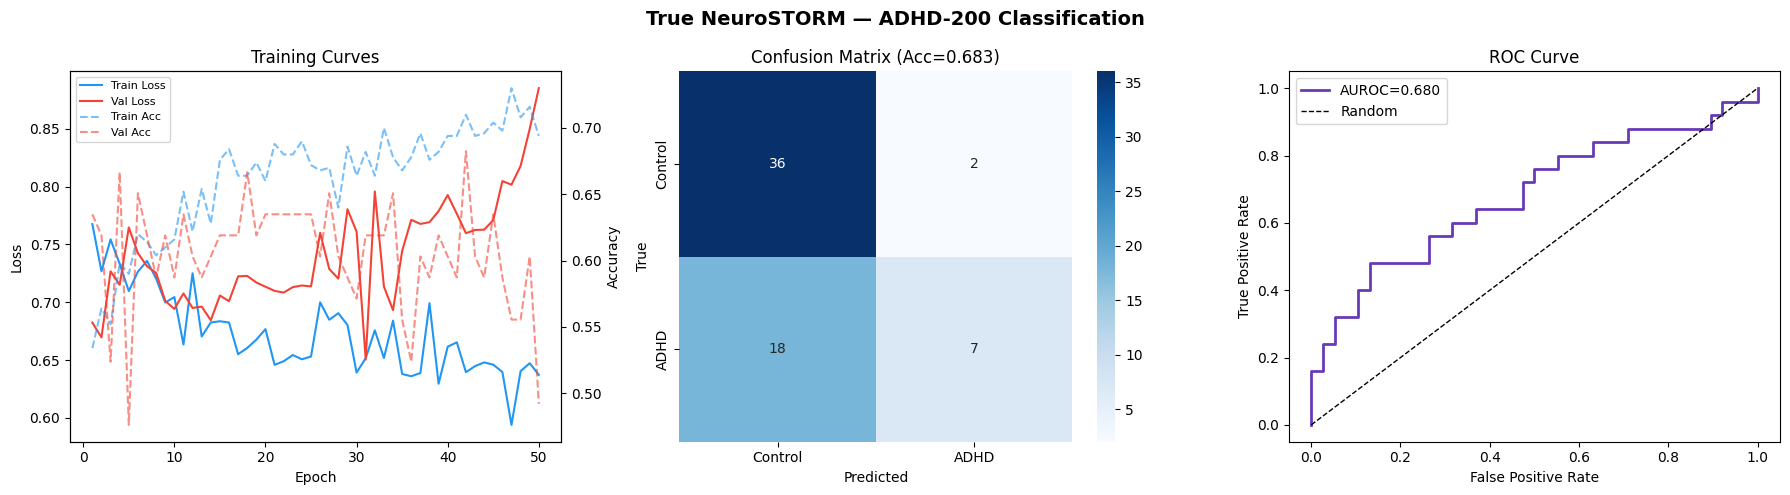

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('True NeuroSTORM — ADHD-200 Classification', fontsize=14, fontweight='bold')

# Training curves
ax = axes[0]
epochs = range(1, len(history['train_loss']) + 1)
ax.plot(epochs, history['train_loss'], label='Train Loss', color='#2196F3')
ax.plot(epochs, history['val_loss'],   label='Val Loss',   color='#F44336')
ax2 = ax.twinx()
ax2.plot(epochs, history['train_acc'], '--', label='Train Acc', color='#2196F3', alpha=0.6)
ax2.plot(epochs, history['val_acc'],   '--', label='Val Acc',   color='#F44336', alpha=0.6)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax2.set_ylabel('Accuracy')
ax.set_title('Training Curves')
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, l1 + l2, fontsize=8)

# Confusion matrix
ax = axes[1]
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Control','ADHD'], yticklabels=['Control','ADHD'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (Acc={acc:.3f})')

# ROC curve
ax = axes[2]
try:
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    ax.plot(fpr, tpr, color='#673AB7', lw=2, label=f'AUROC={auc:.3f}')
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve'); ax.legend()
except:
    ax.text(0.5, 0.5, 'ROC unavailable', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

test_meta = manifest[manifest['split'] == 'test'].reset_index(drop=True)
test_meta = test_meta.iloc[:len(all_labels)].copy()
test_meta['pred'] = all_preds
test_meta['prob'] = all_probs
test_meta['true'] = all_labels

rows = []
for site, grp in test_meta.groupby('site'):
    acc_s = accuracy_score(grp['true'], grp['pred'])
    try:
        auc_s = roc_auc_score(grp['true'], grp['prob'])
    except:
        auc_s = float('nan')
    rows.append({'Site': site, 'N': len(grp), 'Accuracy': acc_s, 'AUROC': auc_s,
                 'ADHD': int(grp['true'].sum()),
                 'Control': int((grp['true']==0).sum())})

site_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
print(site_df.to_string(index=False, float_format='{:.3f}'.format))

print(f'\n── Overall ──')
print(f'Accuracy : {acc:.4f}')
print(f'AUROC    : {auc:.4f}')

      Site  N  Accuracy  AUROC  ADHD  Control
Pittsburgh 13     1.000    NaN     0       13
  Peking_1  8     0.875  0.286     1        7
       KKI  9     0.778  0.571     2        7
       NYU 20     0.600  0.626    13        7
      OHSU  4     0.500  0.000     2        2
NeuroIMAGE  8     0.250  0.833     6        2
     Brown  1     0.000    NaN     1        0

── Overall ──
Accuracy : 0.6825
AUROC    : 0.6800


/home/nvidia/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/nvidia/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
